In [2]:
!pip install opencv-python numpy matplotlib scipy pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os

IMAGE_FOLDER = r"E:\Msc. data\st_neutrino"

files = os.listdir(IMAGE_FOLDER)

print(files[:5])
print("Total images =", len(files))

['spec(0).png', 'spec(1).png', 'spec(10).png', 'spec(11).png', 'spec(12).png']
Total images = 150


Total CSV files = 21

Processing: spec_0.csv


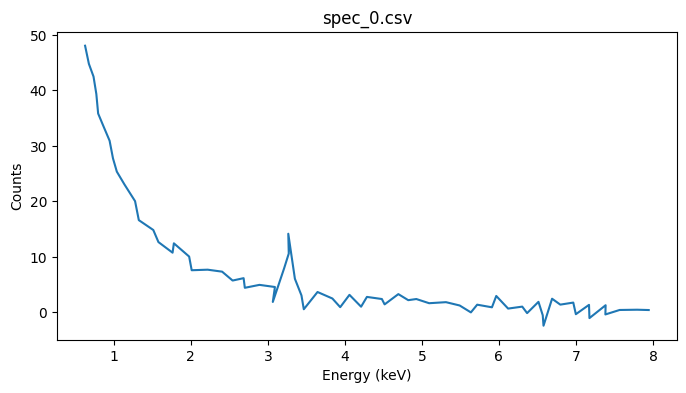


Processing: spec_1.csv


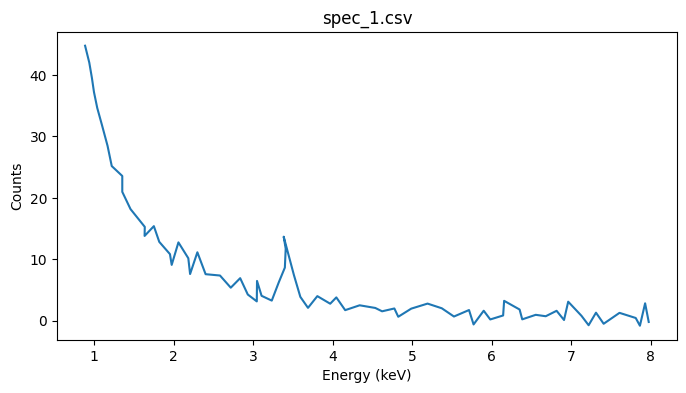


Processing: spec_10.csv


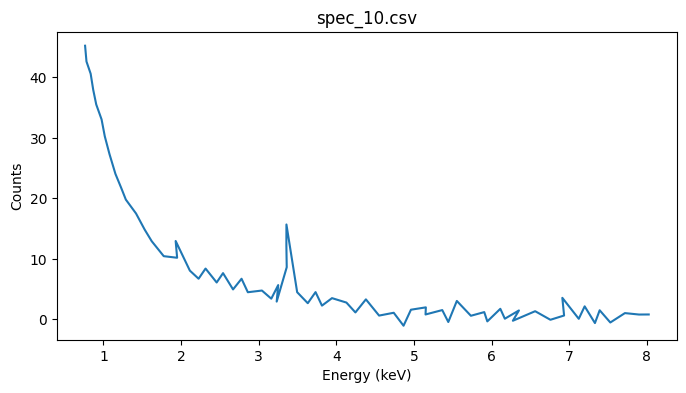


Processing: spec_11.csv


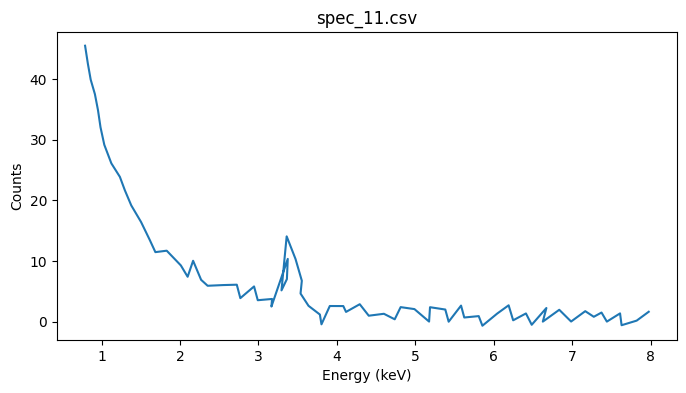


Processing: spec_12.csv


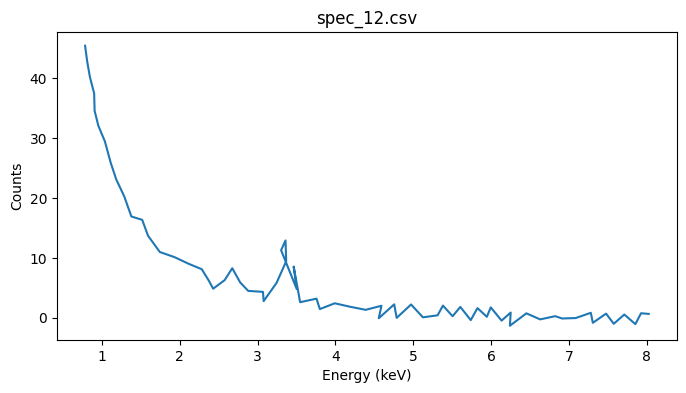


Processing: spec_13.csv


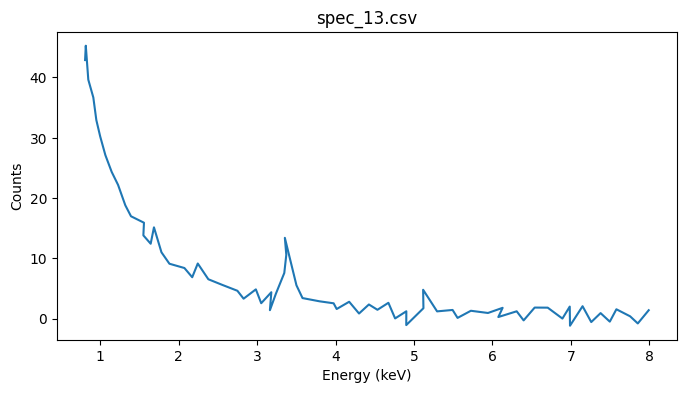


Processing: spec_14.csv


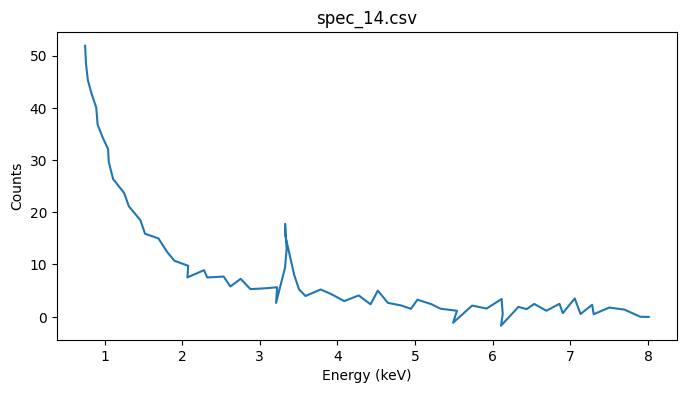


Processing: spec_15.csv


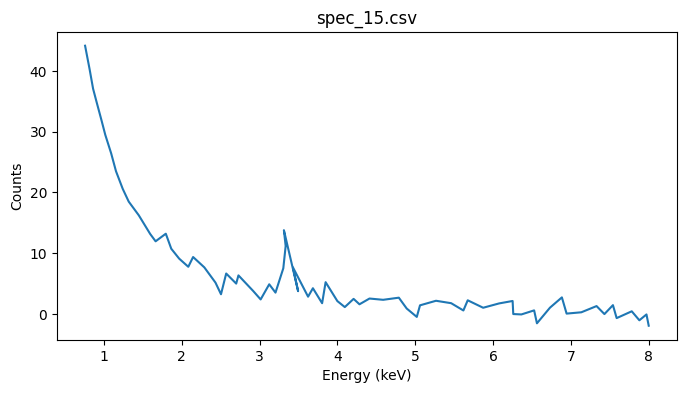


Processing: spec_16.csv


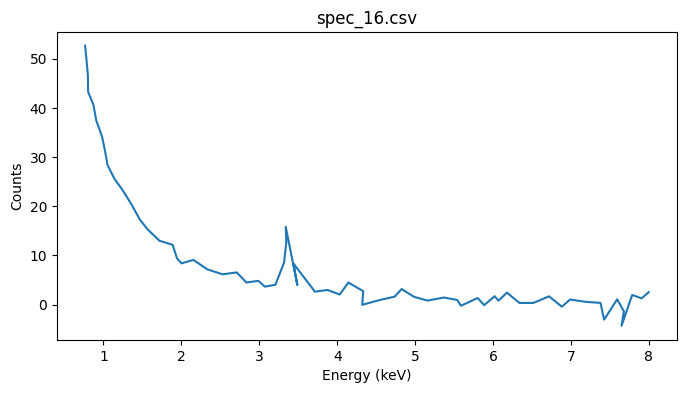


Processing: spec_17.csv


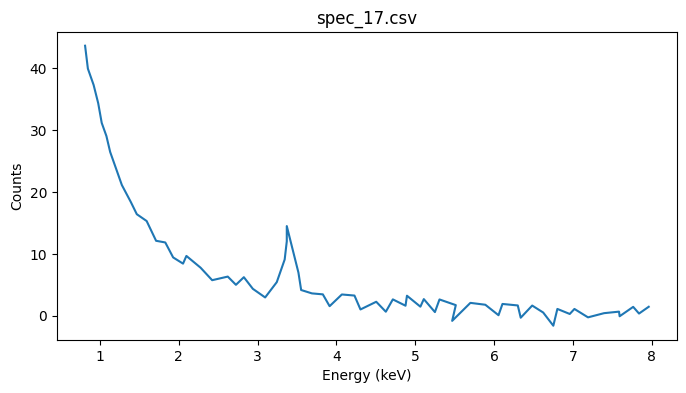


Processing: spec_18.csv


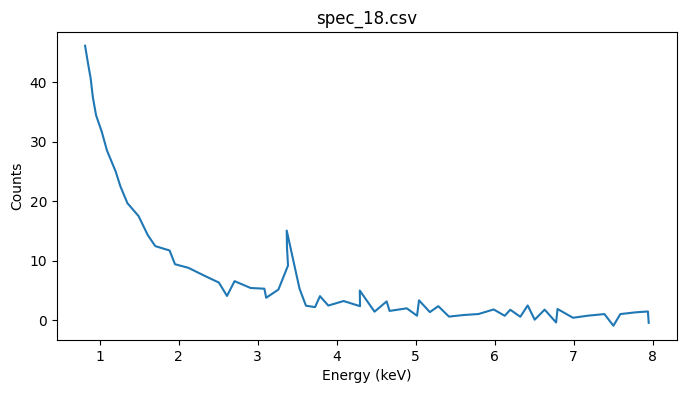


Processing: spec_19.csv


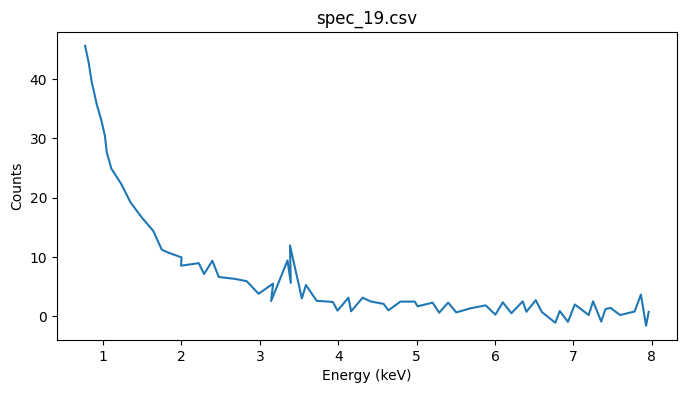


Processing: spec_2.csv


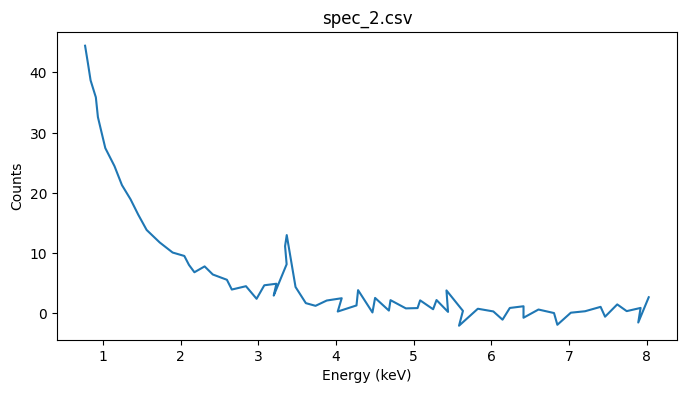


Processing: spec_20.csv


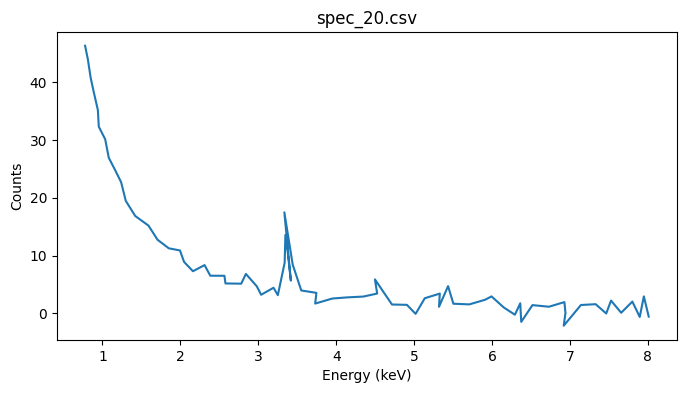


Processing: spec_3.csv


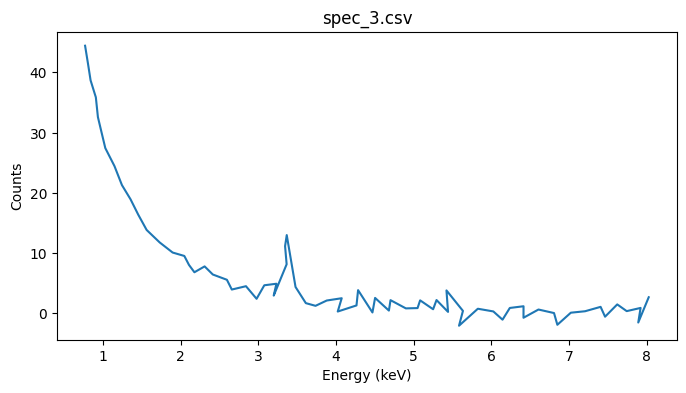


Processing: spec_4.csv


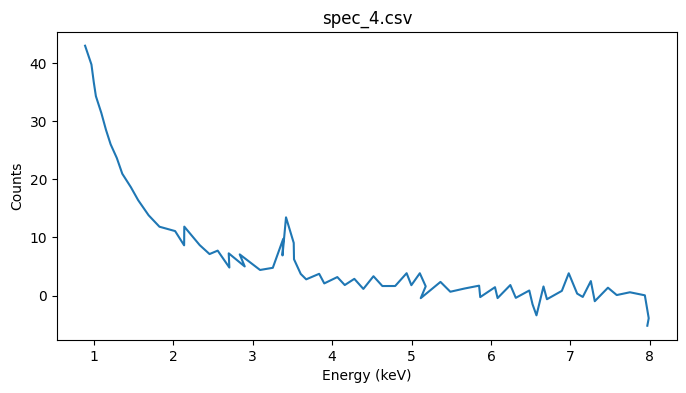


Processing: spec_5.csv


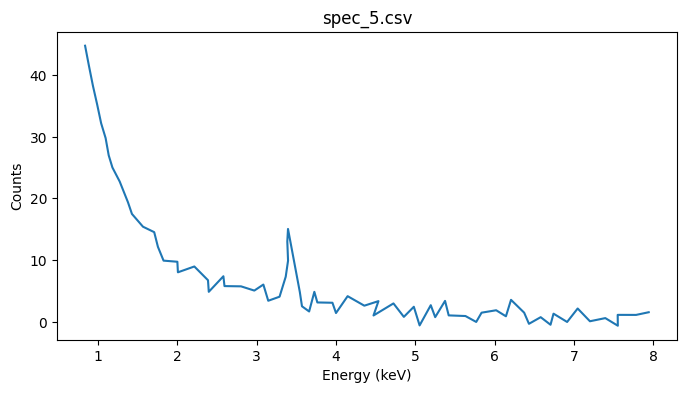


Processing: spec_6.csv


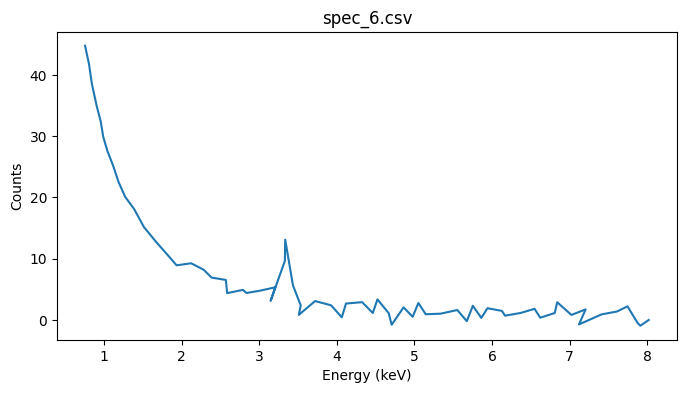


Processing: spec_7.csv


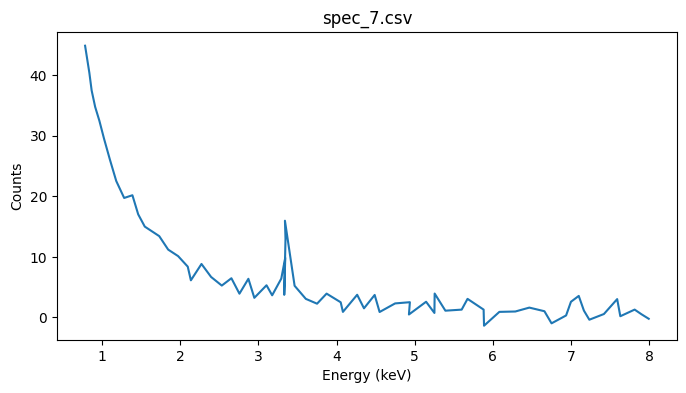


Processing: spec_8.csv


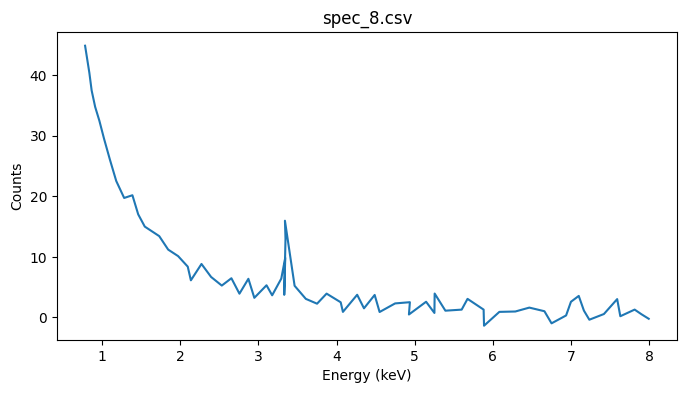


Processing: spec_9.csv


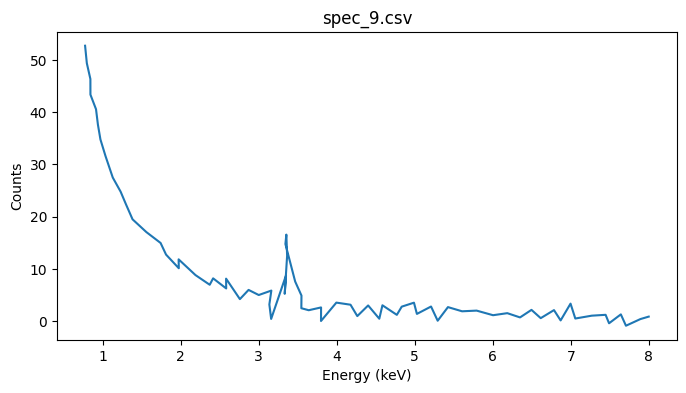

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================================
# FOLDER CONTAINING CSV FILES
# =========================================

FOLDER = r"E:\Msc. data\x_ray observatory"

# =========================================
# GET ALL CSV FILES
# =========================================

csv_files = [
    f for f in os.listdir(FOLDER)
    if f.endswith(".csv")
]

print("Total CSV files =", len(csv_files))

# =========================================
# LOOP OVER FILES
# =========================================

for file in csv_files:

    path = os.path.join(FOLDER, file)

    print("\nProcessing:", file)

    # =====================================
    # LOAD CSV (NO HEADER)
    # =====================================

    df = pd.read_csv(path, header=None)

    # =====================================
    # COLUMN 0 = ENERGY
    # COLUMN 1 = COUNTS
    # =====================================

    energy = df[0]

    counts = df[1]

    # =====================================
    # FIND PEAKS
    # =====================================

    peaks, properties = find_peaks(
        counts,
        prominence=20,
        width=2
    )

    # =====================================
    # PRINT PEAK ENERGIES
    # =====================================

    for p in peaks:

        print(
            "Peak at =",
            energy.iloc[p],
            "keV"
        )

    # =====================================
    # PLOT
    # =====================================

    plt.figure(figsize=(8,4))

    plt.plot(energy, counts)

    plt.scatter(
        energy.iloc[peaks],
        counts.iloc[peaks]
    )

    plt.xlabel("Energy (keV)")
    plt.ylabel("Counts")

    plt.title(file)

    plt.show()

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =====================================================
# FOLDER CONTAINING CSV FILES
# =====================================================

FOLDER = r"E:\Msc. data\x_ray observatory"

# =====================================================
# ENERGY WINDOW
# =====================================================

EMIN = 3.3
EMAX = 3.6

# =====================================================
# GET CSV FILES
# =====================================================

csv_files = [
    f for f in os.listdir(FOLDER)
    if f.endswith(".csv")
]

print("Total spectra =", len(csv_files))

# =====================================================
# COUNTERS
# =====================================================

spectra_with_peak = 0

all_detected_peaks = []

# =====================================================
# LOOP OVER FILES
# =====================================================

for file in csv_files:

    path = os.path.join(FOLDER, file)

    # ==============================================
    # LOAD CSV (NO HEADER)
    # ==============================================

    df = pd.read_csv(path, header=None)

    # COLUMN 0 = ENERGY
    # COLUMN 1 = COUNTS

    energy = df[0]

    counts = df[1]

    # ==============================================
    # FIND PEAKS
    # ==============================================

    peaks, properties = find_peaks(
        counts,
        prominence=2,
        width=1
    )

    found = False

    # ==============================================
    # CHECK PEAK ENERGIES
    # ==============================================

    for p in peaks:

        peak_energy = energy.iloc[p]

        if EMIN <= peak_energy <= EMAX:

            found = True

            all_detected_peaks.append({
                "file": file,
                "peak_energy": peak_energy,
                "counts": counts.iloc[p]
            })

            print(
                f"{file}  --> Peak at {peak_energy:.4f} keV"
            )

    if found:
        spectra_with_peak += 1

# =====================================================
# FINAL STATISTICS
# =====================================================

total_spectra = len(csv_files)

percentage = 100 * spectra_with_peak / total_spectra

print("\n===================================")
print("FINAL STATISTICS")
print("===================================")

print("Total spectra =", total_spectra)

print(
    "Spectra with peaks between "
    f"{EMIN} and {EMAX} keV =",
    spectra_with_peak
)

print(f"Percentage = {percentage:.2f}%")

# =====================================================
# SAVE RESULTS
# =====================================================

results_df = pd.DataFrame(all_detected_peaks)

output_csv = r"E:\Msc. data\peak_statistics.csv"

results_df.to_csv(output_csv, index=False)

print("\nSaved:")
print(output_csv)

Total spectra = 21
spec_1.csv  --> Peak at 3.3847 keV
spec_10.csv  --> Peak at 3.3569 keV
spec_11.csv  --> Peak at 3.3734 keV
spec_11.csv  --> Peak at 3.3595 keV
spec_12.csv  --> Peak at 3.3595 keV
spec_13.csv  --> Peak at 3.3537 keV
spec_14.csv  --> Peak at 3.3260 keV
spec_15.csv  --> Peak at 3.3127 keV
spec_16.csv  --> Peak at 3.3393 keV
spec_17.csv  --> Peak at 3.3696 keV
spec_18.csv  --> Peak at 3.3687 keV
spec_19.csv  --> Peak at 3.3838 keV
spec_2.csv  --> Peak at 3.3659 keV
spec_20.csv  --> Peak at 3.3477 keV
spec_20.csv  --> Peak at 3.3343 keV
spec_3.csv  --> Peak at 3.3659 keV
spec_4.csv  --> Peak at 3.4200 keV
spec_5.csv  --> Peak at 3.3949 keV
spec_6.csv  --> Peak at 3.3344 keV
spec_7.csv  --> Peak at 3.3429 keV
spec_7.csv  --> Peak at 3.3393 keV
spec_8.csv  --> Peak at 3.3429 keV
spec_8.csv  --> Peak at 3.3393 keV
spec_9.csv  --> Peak at 3.3551 keV

FINAL STATISTICS
Total spectra = 21
Spectra with peaks between 3.3 and 3.6 keV = 20
Percentage = 95.24%

Saved:
E:\Msc. data\pe

In [20]:
!pip install astropy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from astropy.io import fits

path = r"E:\Msc. data\XMM data\0305780101\pps\P0305780101M1S001BGSPEC000A.FTZ"

hdul = fits.open(path)

hdul.info()

Filename: E:\Msc. data\XMM data\0305780101\pps\P0305780101M1S001BGSPEC000A.FTZ
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      90   ()      
  1  SPECTRUM      1 BinTableHDU     83   2400R x 2C   [I, J]   
  2  REGION        1 BinTableHDU     23   19R x 4C   [16A, E, E, E]   
  3  GTI00006      1 BinTableHDU     22   7R x 2C   [D, D]   
  4  GTI00106      1 BinTableHDU     22   3R x 2C   [D, D]   
  5  GTI00206      1 BinTableHDU     22   4R x 2C   [D, D]   
  6  GTI00306      1 BinTableHDU     22   4R x 2C   [D, D]   
  7  GTI00406      1 BinTableHDU     22   4R x 2C   [D, D]   
  8  GTI00506      1 BinTableHDU     22   6R x 2C   [D, D]   


In [22]:
data = hdul[1].data

print(data.columns)

ColDefs(
    name = 'CHANNEL'; format = 'I'
    name = 'COUNTS'; format = 'J'; unit = 'count'
)


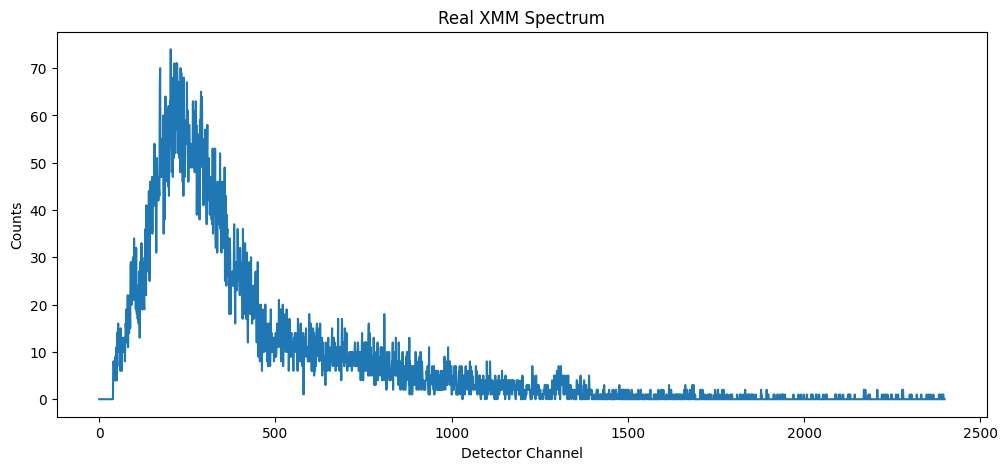

In [23]:
import matplotlib.pyplot as plt

data = hdul[1].data

channel = data['CHANNEL']
counts = data['COUNTS']

plt.figure(figsize=(12,5))

plt.plot(channel, counts)

plt.xlabel("Detector Channel")
plt.ylabel("Counts")

plt.title("Real XMM Spectrum")

plt.show()

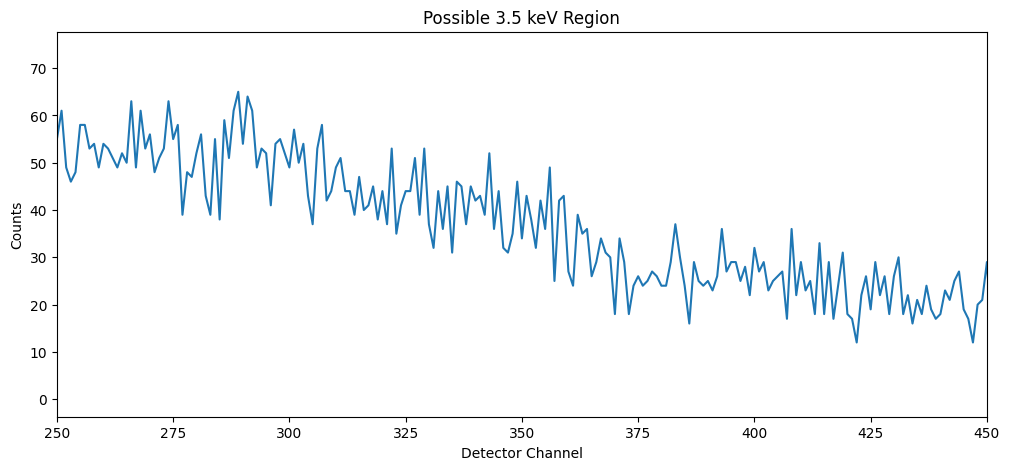

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(channel, counts)

plt.xlim(250, 450)

plt.xlabel("Detector Channel")
plt.ylabel("Counts")

plt.title("Possible 3.5 keV Region")

plt.show()

In [25]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import os
import pandas as pd

folder = r"E:\Msc. data\x_ray observatory\no_line"

files = os.listdir(folder)

print(files[:5])

path = os.path.join(folder, files[0])

df = pd.read_csv(path, header=None)

print(df.head())

print(df.shape)

['spec_0nl.csv', 'spec_10nl.csv', 'spec_11nl.csv', 'spec_12nl.csv', 'spec_13nl.csv']
          0          1
0  0.789807  52.579123
1  0.807661  49.514620
2  0.849318  46.385088
3  0.867171  42.950731
4  0.920136  39.361930
(63, 2)


In [28]:
print(df.head())

          0          1
0  0.789807  52.579123
1  0.807661  49.514620
2  0.849318  46.385088
3  0.867171  42.950731
4  0.920136  39.361930


In [30]:
import os

print(os.path.exists(r"E:\Msc. data\synthetic data\with_line"))

print(os.path.exists(r"E:\Msc. data\synthetic data\no_line"))

True
True


In [33]:
import os

base = r"E:\Msc. data\x_ray observatory"

print(os.listdir(base))

['no_line', 'witl_line']


In [35]:
lengths = []

for spectrum in X:

    lengths.append(len(spectrum))

print(set(lengths))

{64, 65, 66, 67, 68, 69, 70, 71, 72, 61, 62, 63}


In [36]:
def resize_spectrum(spectrum, target_length=65):

    old_indices = np.linspace(0, 1, len(spectrum))

    new_indices = np.linspace(0, 1, target_length)

    resized = np.interp(
        new_indices,
        old_indices,
        spectrum
    )

    return resized

With-line spectra = 26
No-line spectra = 24

Spectrum lengths:
65
65
65
65
65

Dataset shape = (50, 65)
Training samples = 40
Testing samples  = 10

Model training complete.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


CONFUSION MATRIX
[[6 0]
 [0 4]]

Accuracy = 1.0


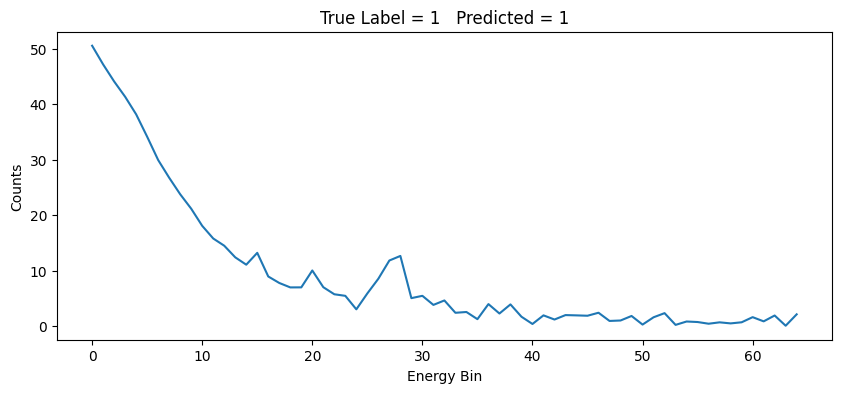

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# =========================================================
# RESIZE FUNCTION
# ALL SPECTRA -> SAME LENGTH
# =========================================================

def resize_spectrum(spectrum, target_length=65):

    old_indices = np.linspace(0, 1, len(spectrum))

    new_indices = np.linspace(0, 1, target_length)

    resized = np.interp(
        new_indices,
        old_indices,
        spectrum
    )

    return resized

# =========================================================
# FOLDERS
# =========================================================

WITH_LINE_FOLDER = r"E:\Msc. data\x_ray observatory\with_line"

NO_LINE_FOLDER = r"E:\Msc. data\x_ray observatory\no_line"

# =========================================================
# DATA ARRAYS
# =========================================================

X = []
y = []

# =========================================================
# LOAD WITH-LINE SPECTRA
# =========================================================

with_line_files = [
    f for f in os.listdir(WITH_LINE_FOLDER)
    if ".csv" in f.lower()
]

print("With-line spectra =", len(with_line_files))

for file in with_line_files:

    path = os.path.join(WITH_LINE_FOLDER, file)

    df = pd.read_csv(path, header=None)

    # COLUMN 1 = COUNTS
    spectrum = df[1].values

    # RESIZE TO SAME LENGTH
    spectrum = resize_spectrum(
        spectrum,
        target_length=65
    )

    X.append(spectrum)

    y.append(1)

# =========================================================
# LOAD NO-LINE SPECTRA
# =========================================================

no_line_files = [
    f for f in os.listdir(NO_LINE_FOLDER)
    if ".csv" in f.lower()
]

print("No-line spectra =", len(no_line_files))

for file in no_line_files:

    path = os.path.join(NO_LINE_FOLDER, file)

    df = pd.read_csv(path, header=None)

    spectrum = df[1].values

    spectrum = resize_spectrum(
        spectrum,
        target_length=65
    )

    X.append(spectrum)

    y.append(0)

# =========================================================
# CHECK LENGTHS
# =========================================================

print("\nSpectrum lengths:")

for s in X[:5]:

    print(len(s))

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X = np.array(X)

y = np.array(y)

print("\nDataset shape =", X.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples =", len(X_train))
print("Testing samples  =", len(X_test))

# =========================================================
# RANDOM FOREST MODEL
# =========================================================

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# =========================================================
# TRAIN MODEL
# =========================================================

model.fit(X_train, y_train)

print("\nModel training complete.")

# =========================================================
# PREDICTIONS
# =========================================================

predictions = model.predict(X_test)

# =========================================================
# RESULTS
# =========================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(classification_report(y_test, predictions))

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

print(confusion_matrix(y_test, predictions))

acc = accuracy_score(y_test, predictions)

print("\nAccuracy =", acc)

# =========================================================
# SHOW ONE TEST SPECTRUM
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(X_test[0])

plt.title(
    f"True Label = {y_test[0]}   Predicted = {predictions[0]}"
)

plt.xlabel("Energy Bin")
plt.ylabel("Counts")

plt.show()

In [40]:
from astropy.io import fits
import numpy as np
import pandas as pd
import os

# =====================================================
# XMM FITS FOLDER
# =====================================================

XMM_FOLDER = r"E:\Msc. data\XMM data\0305780101\pps"

# =====================================================
# RESULTS
# =====================================================

results = []

# =====================================================
# LOOP OVER FTZ FILES
# =====================================================

files = [
    f for f in os.listdir(XMM_FOLDER)
    if ".ftz" in f.lower()
]

print("Total FTZ files =", len(files))

# =====================================================
# PROCESS EACH FILE
# =====================================================

for file in files:

    path = os.path.join(XMM_FOLDER, file)

    try:

        hdul = fits.open(path)

        # ---------------------------------------------
        # CHECK FOR SPECTRUM EXTENSION
        # ---------------------------------------------

        if len(hdul) < 2:
            continue

        data = hdul[1].data

        columns = data.columns.names

        # ---------------------------------------------
        # MUST HAVE COUNTS
        # ---------------------------------------------

        if 'COUNTS' not in columns:
            continue

        counts = data['COUNTS']

        # ---------------------------------------------
        # RESIZE TO ML SIZE
        # ---------------------------------------------

        resized = resize_spectrum(
            counts,
            target_length=65
        )

        # ---------------------------------------------
        # RESHAPE FOR ML
        # ---------------------------------------------

        spectrum = resized.reshape(1, -1)

        # ---------------------------------------------
        # PREDICTION
        # ---------------------------------------------

        prediction = model.predict(spectrum)[0]

        probability = model.predict_proba(spectrum)[0]

        line_probability = probability[1]

        # ---------------------------------------------
        # SAVE RESULT
        # ---------------------------------------------

        results.append({
            "file": file,
            "prediction": prediction,
            "line_probability": line_probability
        })

        print(
            file,
            " --> Line probability = ",
            round(line_probability, 3)
        )

    except Exception as e:

        print("Skipped:", file)

# =====================================================
# SAVE RESULTS
# =====================================================

results_df = pd.DataFrame(results)

output_path = r"E:Msc. data\xmm_ml_results.csv"

results_df.to_csv(output_path, index=False)

print("\nSaved results to:")
print(output_path)

Total FTZ files = 647
P0305780101M1S001BGSPEC0001.FTZ  --> Line probability =  0.77
P0305780101M1S001BGSPEC0002.FTZ  --> Line probability =  0.273
P0305780101M1S001BGSPEC0003.FTZ  --> Line probability =  0.743
P0305780101M1S001BGSPEC0004.FTZ  --> Line probability =  0.753
P0305780101M1S001BGSPEC0005.FTZ  --> Line probability =  0.773
P0305780101M1S001BGSPEC0006.FTZ  --> Line probability =  0.767
P0305780101M1S001BGSPEC0007.FTZ  --> Line probability =  0.747
P0305780101M1S001BGSPEC0008.FTZ  --> Line probability =  0.767
P0305780101M1S001BGSPEC0009.FTZ  --> Line probability =  0.767
P0305780101M1S001BGSPEC000A.FTZ  --> Line probability =  0.317
P0305780101M1S001BGSPEC000B.FTZ  --> Line probability =  0.767
P0305780101M1S001BGSPEC000D.FTZ  --> Line probability =  0.5
P0305780101M1S001BGSPEC000E.FTZ  --> Line probability =  0.467
P0305780101M1S001BGSPEC000F.FTZ  --> Line probability =  0.787
P0305780101M1S001BGSPEC0010.FTZ  --> Line probability =  0.79
P0305780101M1S001BGSPEC0011.FTZ  --> 

In [41]:
# =====================================================
# AVERAGE PROBABILITY
# =====================================================

all_probs = results_df["line_probability"]

average_probability = np.mean(all_probs)

print("\n=================================")
print("AVERAGE LINE PROBABILITY")
print("=================================")

print(
    "Average probability of 3.5 keV-like line =",
    round(average_probability, 4)
)


AVERAGE LINE PROBABILITY
Average probability of 3.5 keV-like line = 0.5262
